In [1]:
from risk_estimation.models.safety_layer import get_risk_estimator
from risk_estimation.datasets.frame_dropping import NoFrameDroppingPolicy
from risk_estimation.datasets.risk_dataloader import RiskEstimationDataset as D
from risk_estimation.datasets.risk_feature_extractor import *
from risk_estimation.datasets.frame_dropping import *
from risk_estimation.result_evaluator import benchmark_eval_save
from risk_estimation.scripts.result_img_save import sample_and_save_on_video, video_triplets_save
from video_embedding.models.video_embedder import VideoEmbedder
from video_embedding.utils import all_test_names, all_trial_names, all_novel_names, set_session

/home/petr/miniconda3/envs/ilesia/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/petr/miniconda3/envs/ilesia/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
features: str = StampedLatentObservationsRiskLabels # StampedLatent (h+alpha) (is default) 
set_session("AE3")

RangedFramesDroppingPolicy.mintestcut = 200
RangedFramesDroppingPolicy.maxtestcut = 400
FalseAlarmEvaluationPolicy = RangedFramesDroppingPolicy

# RangedFramesDroppingPolicy.mintestcut = 0
# RangedFramesDroppingPolicy.maxtestcut = 110
# dataloader_ood1 = D.load_dataloader(["peg_pick404_novel_8"], pick_gp.video_embedder, 64, RangedFramesDroppingPolicy, features)
# RangedFramesDroppingPolicy.mintestcut = 130
# RangedFramesDroppingPolicy.maxtestcut = 700
# dataloader_ood2 = D.load_dataloader(["peg_pick404_novel_8"], pick_gp.video_embedder, 64, RangedFramesDroppingPolicy, features)
# nodrop_train_dataloader_ood = DataLoader(nodrop_dataloader.dataset + dataloader_ood1.dataset + dataloader_ood2.dataset, batch_size=64)
# pick_gp.train_valid(nodrop_train_dataloader_ood, test_dataloader, novel_dataloader)

In [3]:
class SafetyLayer:
    def __init__(self, skill_name, approach, train_epoch=400, window_size=3):
        self.skill_name = skill_name
        self.video_embedder = VideoEmbedder(name=skill_name, latent_dim=12, nn_model="Autoencoder3")
        self.video_embedder.load_model()

        self.estimator = get_risk_estimator(
            approach, skill_name, features.xdim(12), self.video_embedder, "cautious", train_epoch, train_epoch
        )
        self.estimator.WINDOW_SIZE = window_size
        
    def train_valid(self, train_dataloader, test_dataloader, novel_dataloader=None, falsealarmeval_dataloader=None):
        self.estimator.set_dataloaders_for_validation([test_dataloader], names=["test"])
        self.estimator.training_loop(train_dataloader, early_stop=True)
        self.estimator.save_model()

        benchmark_eval_save("Train_dataset", self.skill_name, train_dataloader.dataset, self.video_embedder, self.estimator)
        benchmark_eval_save("Test_dataset", self.skill_name, test_dataloader.dataset, self.video_embedder, self.estimator)
        # benchmark_eval_save("Novel_Dataset (before filter)", self.skill_name, novel_dataloader.dataset, self.video_embedder, self.estimator)
        if falsealarmeval_dataloader is not None:
            benchmark_eval_save("FalseAlarm_Dataset", self.skill_name, falsealarmeval_dataloader.dataset, self.video_embedder, self.estimator)

        video_names = train_dataloader.dataset.video_names + test_dataloader.dataset.video_names
        if novel_dataloader is not None:
            video_names = video_names + novel_dataloader.dataset.video_names
        for video_name in video_names:
            sample_and_save_on_video(video_name, self.video_embedder, self.estimator, features, train_dataloader, folder="autogen")
            video_triplets_save(video_name, self.video_embedder, folder="autogen")

In [4]:
pick_gp_W0 = SafetyLayer(skill_name = "peg_pick404", approach = 'TwinGP', window_size=5)
pick_mlp_W0 = SafetyLayer(skill_name = "peg_pick404", approach = 'MLP2', window_size=1)
door_gp_W0 = SafetyLayer(skill_name = "peg_door404", approach = 'TwinGP', window_size=5)
door_mlp_W0 = SafetyLayer(skill_name = "peg_door404", approach = 'MLP2', window_size=1)
place_gp_W0 = SafetyLayer(skill_name = "peg_place404", approach = 'TwinGP', window_size=5)
place_mlp_W0 = SafetyLayer(skill_name = "peg_place404", approach = 'MLP2', window_size=1)

Loading model: /home/petr/ilesia_ws/src/ILeSiA/video_embedding/saved_models/AE3/peg_pick404_Autoencoder3_12.pt
Loading model: /home/petr/ilesia_ws/src/ILeSiA/video_embedding/saved_models/AE3/peg_pick404_Autoencoder3_12.pt
Loading model: /home/petr/ilesia_ws/src/ILeSiA/video_embedding/saved_models/AE3/peg_door404_Autoencoder3_12.pt
Loading model: /home/petr/ilesia_ws/src/ILeSiA/video_embedding/saved_models/AE3/peg_door404_Autoencoder3_12.pt
Loading model: /home/petr/ilesia_ws/src/ILeSiA/video_embedding/saved_models/AE3/peg_place404_Autoencoder3_12.pt
Loading model: /home/petr/ilesia_ws/src/ILeSiA/video_embedding/saved_models/AE3/peg_place404_Autoencoder3_12.pt


## Pick

In [5]:
all_trial_names(pick_gp_W0.skill_name)

['peg_pick404_trial_0',
 'peg_pick404_trial_1',
 'peg_pick404_trial_2',
 'peg_pick404_trial_3',
 'peg_pick404']

In [6]:
trialnames = all_trial_names(pick_gp_W0.skill_name) + ["peg_pick404_novel_0"] # peg_pick404_novel_0 is for a reference and not include novel faults 
testnames =  all_test_names( pick_gp_W0.skill_name)
novelnames = all_novel_names(pick_gp_W0.skill_name)

labeled_dataloader = D.load_dataloader(trialnames, pick_gp_W0.video_embedder, 64, OnlyLabelledFramesDroppingPolicy, features)
full_dataloader = D.load_dataloader(trialnames, pick_gp_W0.video_embedder, 64, NoFrameDroppingPolicy, features)

test_dataloader = D.load_dataloader(testnames, pick_gp_W0.video_embedder, 64, OnlyLabelledFramesDroppingPolicy, features)
novel_dataloader = D.load_dataloader(novelnames, pick_gp_W0.video_embedder, 64, OnlyLabelledFramesDroppingPolicy, features)
falsealarmeval_dataloader = D.load_dataloader(trialnames + testnames + novelnames, pick_gp_W0.video_embedder, 64, FalseAlarmEvaluationPolicy, features)

/home/petr/miniconda3/envs/ilesia/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


training new dataloader
Has  analytical likelihood:
True


Tr:  93%, Test:  70%, loss: -0.631: 100%|██████████| 400/400 [00:18<00:00, 21.25it/s]


Continuing with the rest of the program
Training finished
training new dataloader
Has  analytical likelihood:
True


Tr:  89%, Test:  69%, loss: -0.724: 100%|██████████| 400/400 [00:19<00:00, 20.75it/s]


Continuing with the rest of the program
Training finished
The AE3 peg_pick404  Train_dataset_GP__cautious_xdim13_ptnce400_lr0.01_ep400_twin has 99.4% Samples: 3795, Risky: 398, Safe: 3397


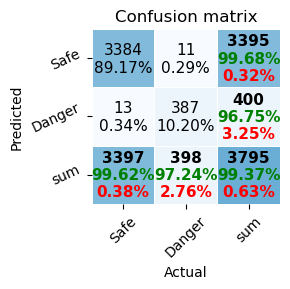

The AE3 peg_pick404  Test_dataset_GP__cautious_xdim13_ptnce400_lr0.01_ep400_twin has 91.8% Samples: 8793, Risky: 3007, Safe: 5786


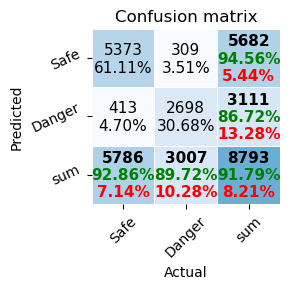

The AE3 peg_pick404  FalseAlarm_Dataset_GP__cautious_xdim13_ptnce400_lr0.01_ep400_twin has 91.8% Samples: 10826, Risky: 96, Safe: 10730


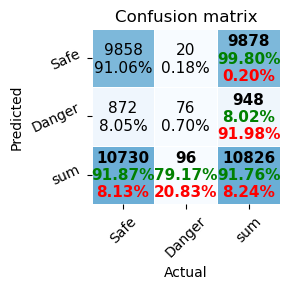

/home/petr/miniconda3/envs/ilesia/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Saved video: peg_pick404_trial_0 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_trial_1 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_trial_2 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_trial_3 with 619 frames and lenth 20.6s.
Saved video: peg_pick404 with 620 frames and lenth 20.7s.
Saved video: peg_pick404_novel_0 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_0 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_1 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_2 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_3 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_4 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_5 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_6 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_7 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_8 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_te

Tr:  99%, Test:  92%, loss: 0.049: 100%|██████████| 400/400 [00:36<00:00, 11.01it/s]


The AE3 peg_pick404  Train_dataset_MLP2___xdim13_ptnce400_lr0.001_ep0 has 99.5% Samples: 2797, Risky: 398, Safe: 2399


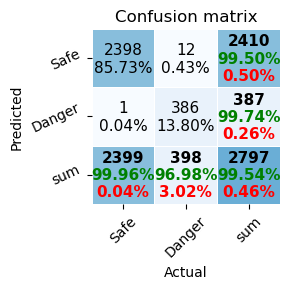

The AE3 peg_pick404  Test_dataset_MLP2___xdim13_ptnce400_lr0.001_ep0 has 91.9% Samples: 8793, Risky: 3007, Safe: 5786


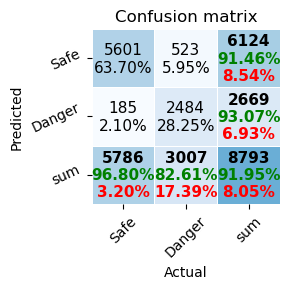

The AE3 peg_pick404  FalseAlarm_Dataset_MLP2___xdim13_ptnce400_lr0.001_ep0 has 99.9% Samples: 10826, Risky: 96, Safe: 10730


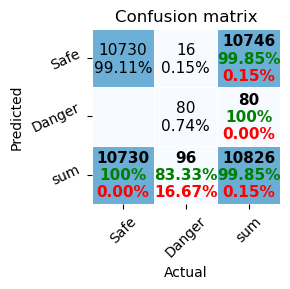

/home/petr/miniconda3/envs/ilesia/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Saved video: peg_pick404_trial_0 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_trial_1 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_trial_2 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_trial_3 with 619 frames and lenth 20.6s.
Saved video: peg_pick404 with 620 frames and lenth 20.7s.
Saved video: peg_pick404_novel_0 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_0 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_1 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_2 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_3 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_4 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_5 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_6 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_7 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_test_8 with 619 frames and lenth 20.6s.
Saved video: peg_pick404_te

In [7]:
# pick_gp_W0.train_valid(labeled_dataloader, test_dataloader, novel_dataloader, falsealarmeval_dataloader)
pick_gp_W0.train_valid(full_dataloader, test_dataloader, novel_dataloader, falsealarmeval_dataloader)
pick_mlp_W0.train_valid(labeled_dataloader, test_dataloader, novel_dataloader, falsealarmeval_dataloader)

# Open Door

In [8]:
trialnames = all_trial_names(door_gp_W0.skill_name) + ["peg_door404_novel_10"] # peg_door404_novel_10 is for a reference and not include novel faults 
testnames = all_test_names(door_gp_W0.skill_name)
novelnames = all_novel_names(door_gp_W0.skill_name)

labeled_dataloader = D.load_dataloader(trialnames, door_gp_W0.video_embedder, 64, OnlyLabelledFramesDroppingPolicy, features)
full_dataloader = D.load_dataloader(trialnames, door_gp_W0.video_embedder, 64, NoFrameDroppingPolicy, features)

test_dataloader = D.load_dataloader(testnames, door_gp_W0.video_embedder, 64, OnlyLabelledFramesDroppingPolicy, features)
novel_dataloader = D.load_dataloader(novelnames, door_gp_W0.video_embedder, 64, OnlyLabelledFramesDroppingPolicy, features)
falsealarmeval_dataloader = D.load_dataloader(trialnames + testnames + novelnames, door_gp_W0.video_embedder, 64, FalseAlarmEvaluationPolicy, features)

training new dataloader
Has  analytical likelihood:
True


Tr:  85%, Test:  73%, loss: -0.707: 100%|██████████| 400/400 [01:04<00:00,  6.24it/s]


Continuing with the rest of the program
Training finished
training new dataloader
Has  analytical likelihood:
True


Tr:  88%, Test:  69%, loss: -0.725: 100%|██████████| 400/400 [01:01<00:00,  6.48it/s]


Continuing with the rest of the program
Training finished
The AE3 peg_door404  Train_dataset_GP__cautious_xdim13_ptnce400_lr0.01_ep400_twin has 98.8% Samples: 9273, Risky: 1494, Safe: 7779


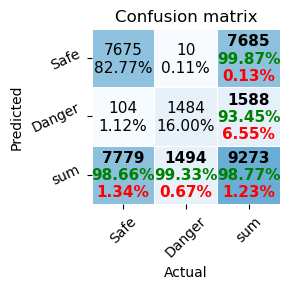

The AE3 peg_door404  Test_dataset_GP__cautious_xdim13_ptnce400_lr0.01_ep400_twin has 99.2% Samples: 11732, Risky: 3814, Safe: 7918


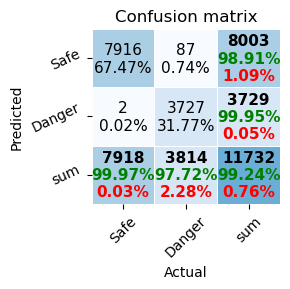

The AE3 peg_door404  FalseAlarm_Dataset_GP__cautious_xdim13_ptnce400_lr0.01_ep400_twin has 95.8% Samples: 10826, Risky: 833, Safe: 9993


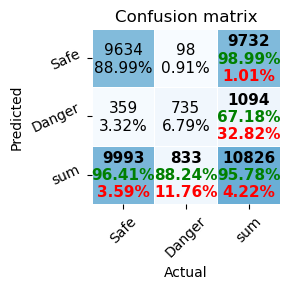

/home/petr/miniconda3/envs/ilesia/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Saved video: peg_door404_trial_0 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_1 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_2 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_3 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_4 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_5 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_6 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_7 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_8 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_9 with 766 frames and lenth 25.5s.
Saved video: peg_door404 with 767 frames and lenth 25.6s.
Saved video: peg_door404_novel_10 with 766 frames and lenth 25.5s.
Saved video: peg_door404_test_0 with 766 frames and lenth 25.5s.
Saved video: peg_door404_test_1 with 766 frames and lenth 25.5s.
Saved video: peg_door404_test_2 with 766 frames and lenth 25.5s.
Saved video: peg_doo

Tr:  99%, Test:  93%, loss: 0.033: 100%|██████████| 400/400 [02:14<00:00,  2.97it/s]


The AE3 peg_door404  Train_dataset_MLP2___xdim13_ptnce400_lr0.001_ep0 has 98.8% Samples: 9273, Risky: 1494, Safe: 7779


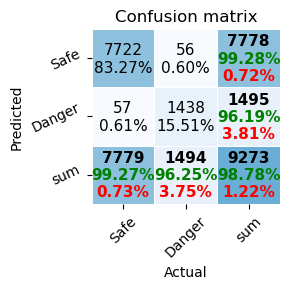

The AE3 peg_door404  Test_dataset_MLP2___xdim13_ptnce400_lr0.001_ep0 has 93.0% Samples: 11732, Risky: 3814, Safe: 7918


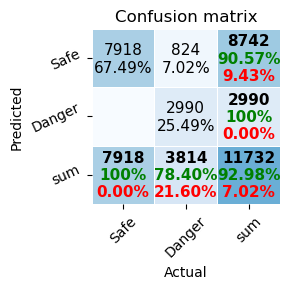

The AE3 peg_door404  FalseAlarm_Dataset_MLP2___xdim13_ptnce400_lr0.001_ep0 has 96.2% Samples: 10826, Risky: 833, Safe: 9993


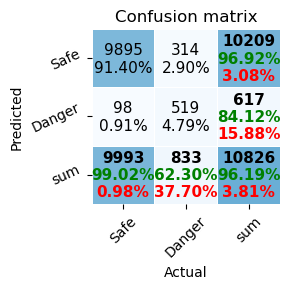

/home/petr/miniconda3/envs/ilesia/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Saved video: peg_door404_trial_0 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_1 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_2 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_3 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_4 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_5 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_6 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_7 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_8 with 766 frames and lenth 25.5s.
Saved video: peg_door404_trial_9 with 766 frames and lenth 25.5s.
Saved video: peg_door404 with 767 frames and lenth 25.6s.
Saved video: peg_door404_novel_10 with 766 frames and lenth 25.5s.
Saved video: peg_door404_test_0 with 766 frames and lenth 25.5s.
Saved video: peg_door404_test_1 with 766 frames and lenth 25.5s.
Saved video: peg_door404_test_2 with 766 frames and lenth 25.5s.
Saved video: peg_doo

In [9]:
# door_gp_W0.train_valid(labeled_dataloader, test_dataloader,novel_dataloader, falsealarmeval_dataloader)
door_gp_W0.train_valid(full_dataloader, test_dataloader, novel_dataloader, falsealarmeval_dataloader)
door_mlp_W0.train_valid(full_dataloader, test_dataloader, novel_dataloader, falsealarmeval_dataloader)

# Place

In [10]:
trialnames = all_trial_names(place_gp_W0.skill_name) + ["peg_place404_novel_1"] # peg_place404_novel_1 is for a reference and not include novel faults 
testnames = all_test_names(place_gp_W0.skill_name)
novelnames = all_novel_names(place_gp_W0.skill_name)

labeled_dataloader = D.load_dataloader(trialnames, place_gp_W0.video_embedder, 64, OnlyLabelledFramesDroppingPolicy, features)
full_dataloader = D.load_dataloader(trialnames, place_gp_W0.video_embedder, 64, NoFrameDroppingPolicy, features)

test_dataloader = D.load_dataloader(testnames, place_gp_W0.video_embedder, 64, OnlyLabelledFramesDroppingPolicy, features)
novel_dataloader = D.load_dataloader(novelnames, place_gp_W0.video_embedder, 64, OnlyLabelledFramesDroppingPolicy, features)
falsealarmeval_dataloader = D.load_dataloader(trialnames + testnames + novelnames, place_gp_W0.video_embedder, 64, FalseAlarmEvaluationPolicy, features)

Tr: 100%, Test:  93%, loss: 0.013: 100%|██████████| 400/400 [01:00<00:00,  6.64it/s]


The AE3 peg_place404  Train_dataset_MLP2___xdim13_ptnce400_lr0.001_ep0 has 100.0% Samples: 3303, Risky: 260, Safe: 3043


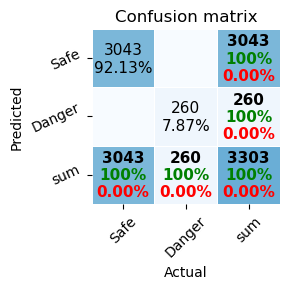

The AE3 peg_place404  Test_dataset_MLP2___xdim13_ptnce400_lr0.001_ep0 has 93.4% Samples: 6743, Risky: 1785, Safe: 4958


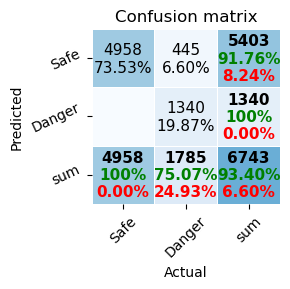

The AE3 peg_place404  FalseAlarm_Dataset_MLP2___xdim13_ptnce400_lr0.001_ep0 has 100.0% Samples: 9035, Risky: 80, Safe: 8955


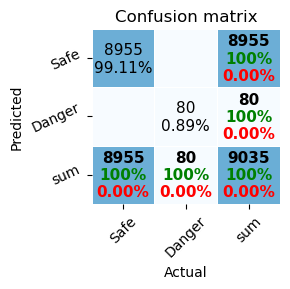

/home/petr/miniconda3/envs/ilesia/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Saved video: peg_place404_trial_0 with 537 frames and lenth 17.9s.
Saved video: peg_place404_trial_1 with 537 frames and lenth 17.9s.
Saved video: peg_place404_trial_2 with 537 frames and lenth 17.9s.
Saved video: peg_place404_trial_3 with 537 frames and lenth 17.9s.
Saved video: peg_place404 with 538 frames and lenth 17.9s.
Saved video: peg_place404_novel_1 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_0 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_1 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_2 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_3 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_4 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_5 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_6 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_7 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_8 with 537 frames and lenth 17.9s.
Saved video:

In [11]:
# place_gp_W0.train_valid(labeled_dataloader, test_dataloader,novel_dataloader, falsealarmeval_dataloader)
# place_gp_W0.train_valid(full_dataloader, test_dataloader, novel_dataloader, falsealarmeval_dataloader)
place_mlp_W0.train_valid(full_dataloader, test_dataloader, novel_dataloader, falsealarmeval_dataloader)

training new dataloader
Has  analytical likelihood:
True


Tr:  92%, Test:  74%, loss: -0.855: 100%|██████████| 400/400 [00:17<00:00, 23.19it/s]


Continuing with the rest of the program
Training finished
training new dataloader
Has  analytical likelihood:
True


Tr:  95%, Test:  76%, loss: -0.802: 100%|██████████| 400/400 [00:15<00:00, 25.82it/s]


Continuing with the rest of the program
Training finished
The AE3 peg_place404  Train_dataset_GP__cautious_xdim13_ptnce400_lr0.01_ep400_twin has 99.8% Samples: 3303, Risky: 260, Safe: 3043


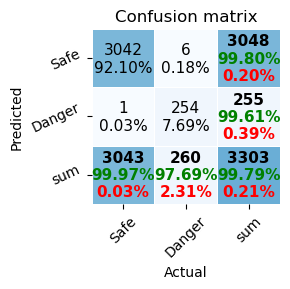

The AE3 peg_place404  Test_dataset_GP__cautious_xdim13_ptnce400_lr0.01_ep400_twin has 94.6% Samples: 6743, Risky: 1785, Safe: 4958


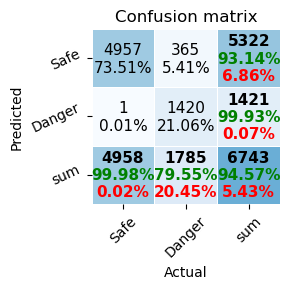

The AE3 peg_place404  FalseAlarm_Dataset_GP__cautious_xdim13_ptnce400_lr0.01_ep400_twin has 99.9% Samples: 9035, Risky: 80, Safe: 8955


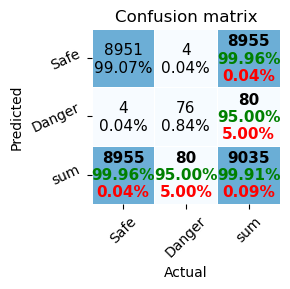

/home/petr/miniconda3/envs/ilesia/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Saved video: peg_place404_trial_0 with 537 frames and lenth 17.9s.
Saved video: peg_place404_trial_1 with 537 frames and lenth 17.9s.
Saved video: peg_place404_trial_2 with 537 frames and lenth 17.9s.
Saved video: peg_place404_trial_3 with 537 frames and lenth 17.9s.
Saved video: peg_place404 with 538 frames and lenth 17.9s.
Saved video: peg_place404_novel_1 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_0 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_1 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_2 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_3 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_4 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_5 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_6 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_7 with 537 frames and lenth 17.9s.
Saved video: peg_place404_test_8 with 537 frames and lenth 17.9s.
Saved video:

In [12]:
place_gp_W0.train_valid(full_dataloader, test_dataloader, novel_dataloader, falsealarmeval_dataloader)